In [1]:
from torchvision import datasets, transforms
import os
import torch
import torch.nn as nn

data_path = "../../data/cifar-10/"
os.makedirs(data_path, exist_ok=True)
cifar10 = datasets.CIFAR10(data_path, train=True, download=True)
cifar10_val = datasets.CIFAR10(data_path, train=False, download=True)

label_map = {0: 0, 2:1}
class_names = ['airplane', 'bird']

tensor_cifar10 = datasets.CIFAR10(data_path, train=True, download=False,
                                  transform=transforms.ToTensor())
imgs = torch.stack([img_t for img_t, _ in tensor_cifar10], dim=3)
mean = imgs.view(3, -1).mean(dim=1)
std = imgs.view(3, -1).std(dim=1)

transform_func = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

cifar2 = [(transform_func(img), label_map[label]) for img, label in cifar10 if label in [0, 2]]
cifar2_val = [(transform_func(img), label_map[label]) for img, label in cifar10_val if label in [0, 2]]

In [2]:
# 3 represents the number of input channels (typically for a colored image with red, green, and blue channels).
# 16 represents the number of output channels.
conv = nn.Conv2d(3, 16, kernel_size=3)
conv

# So, this layer is designed to take input data with 3 channels, apply 16 different 3 * 3 convolutional filters to it,
# and produce 16 output channels as a result.

Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1))

In [3]:
conv.weight.shape, conv.bias.shape

(torch.Size([16, 3, 3, 3]), torch.Size([16]))

In [4]:
img, _ = cifar2[0]
output = conv(img.unsqueeze(0))
img.unsqueeze(0).shape, output.shape

(torch.Size([1, 3, 32, 32]), torch.Size([1, 16, 30, 30]))

In [5]:
conv = nn.Conv2d(3, 1, kernel_size=3, padding=1)
output = conv(img.unsqueeze(0))
img.unsqueeze(0).shape, output.shape

(torch.Size([1, 3, 32, 32]), torch.Size([1, 1, 32, 32]))

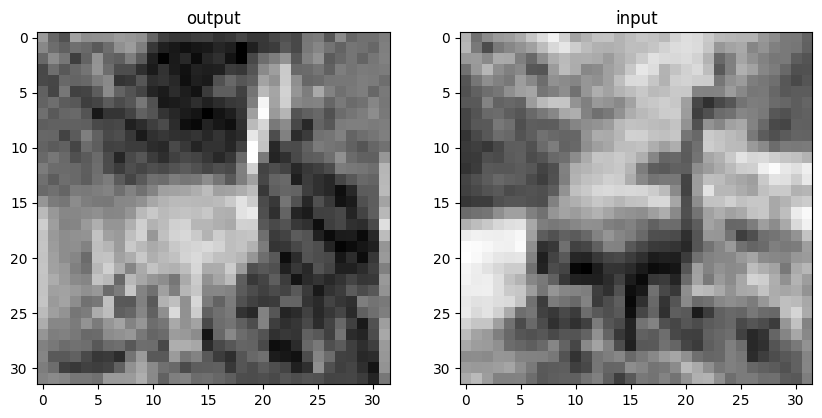

In [6]:
import matplotlib.pyplot as plt

def plot_img(img, output):
    plt.figure(figsize=(10, 4.8))
    ax1 = plt.subplot(1, 2, 1)
    plt.title('output')
    plt.imshow(output[0, 0].detach(), cmap='gray')
    plt.subplot(1, 2, 2, sharex=ax1, sharey=ax1)
    plt.imshow(img.mean(0), cmap='gray')
    plt.title('input')
    plt.show()

plot_img(img, output)

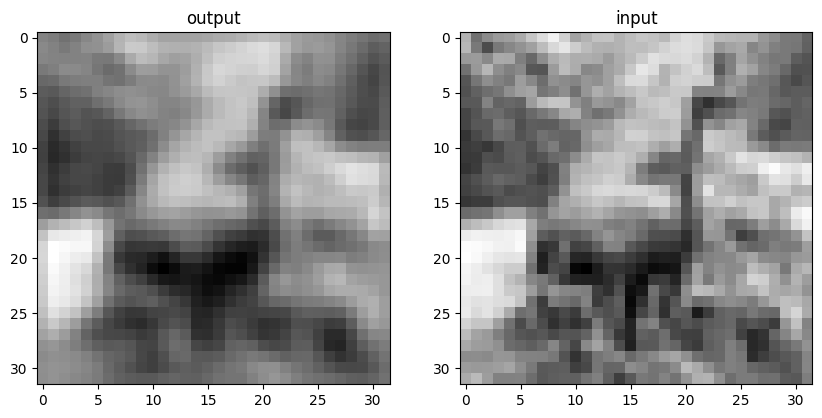

In [7]:
with torch.no_grad():
    conv.bias.zero_()
    
with torch.no_grad():
    conv.weight.fill_(1.0 / 9.0)

output = conv(img.unsqueeze(0))
plot_img(img, output)

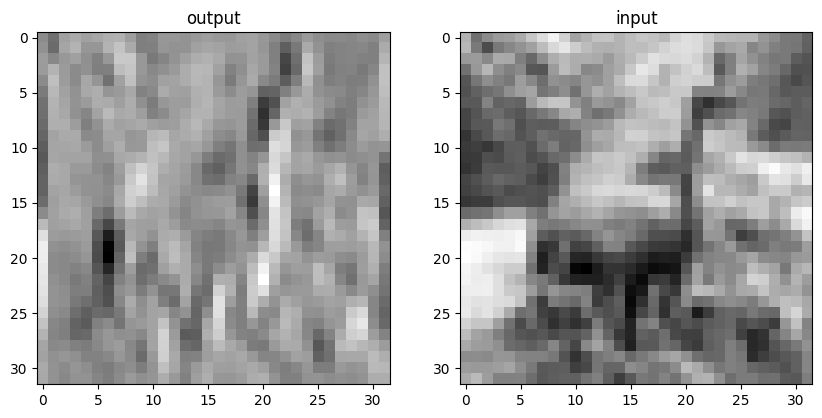

In [8]:
with torch.no_grad():
    conv.weight[:] = torch.tensor([
        [-1.0, 0.0, 1.0],
        [-1.0, 0.0, 1.0],
        [-1.0, 0.0, 1.0]
    ])
    conv.bias.zero_()

output = conv(img.unsqueeze(0))
plot_img(img, output)

In [9]:
# Subclass of nn.Module
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.act1 = nn.Tanh()
        self.pool1 = nn.MaxPool2d(2)
        
        self.conv2 = nn.Conv2d(16, 8, kernel_size=3, padding=1)
        self.act2 = nn.Tanh()
        self.pool2 = nn.MaxPool2d(2)
        
        self.fc1 = nn.Linear(8 * 8 * 8, 32)
        self.act3 = nn.Tanh()
        self.fc2 = nn.Linear(32, 2)
        
    def forward(self, x):
        out = self.pool1(self.act1(self.conv1(x)))
        out = self.pool2(self.act2(self.conv2(out)))
        out = out.view(-1, 8 * 8 * 8)
        out = self.act3(self.fc1(out))
        out = self.fc2(out)
        return out

In [10]:
model = Net()
num_list = [p.numel() for p in model.parameters()]
sum(num_list), num_list

(18090, [432, 16, 1152, 8, 16384, 32, 64, 2])

In [11]:
# It's a waste that we also registering submodules that have no parameters,like nn.Tanh and nn.MaxPool2d
import torch.nn.functional as F
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 8, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(8 * 8 * 8,  32)
        self.fc2 = nn.Linear(32, 2)
        
    def forward(self, x):
        out = F.max_pool2d(torch.tanh(self.conv1(x)), 2)
        out = F.max_pool2d(torch.tanh(self.conv2(out)), 2)
        out = out.view(-1, 8 * 8 * 8)
        out = torch.tanh(self.fc1(out))
        out = self.fc2(out)
        return out

In [12]:
model = Net()
model(img.unsqueeze(0))

tensor([[ 0.1656, -0.0800]], grad_fn=<AddmmBackward0>)

In [13]:
import datetime

def training_loop(n_epochs, optimizer, model, loss_fn, train_loader):
    for epoch in range(1, n_epochs + 1):
        start_time = datetime.datetime.now()
        loss_train = 0.0
        for imgs, labels in train_loader:
            outputs = model(imgs)
            loss = loss_fn(outputs, labels)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            loss_train += loss.item()
        end_time = datetime.datetime.now()
        epoch_duration = (end_time - start_time).total_seconds()
        
        if epoch == 1 or epoch % 10 == 0:
            print("{} Epoch {}, Training loss {:.6f}, Time {:.2f}s".format(
                datetime.datetime.now(), epoch,
                loss_train / len(train_loader),
                epoch_duration
            ))

In [14]:
import torch.optim as optim

train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64, shuffle=True)
model = Net()
optimizer = optim.SGD(model.parameters(), lr=1e-2)
loss_fn = nn.CrossEntropyLoss()

training_loop(
    n_epochs=100,
    optimizer=optimizer,
    model=model,
    loss_fn=loss_fn,
    train_loader=train_loader
)

2026-09-11 17:47:22.779195 Epoch 1, Training loss 0.579030, Time 11.26s
2026-09-11 17:49:04.956041 Epoch 10, Training loss 0.339960, Time 11.42s
2026-09-11 17:50:43.645111 Epoch 20, Training loss 0.299214, Time 3.18s
2026-09-11 17:51:08.814831 Epoch 30, Training loss 0.275552, Time 2.36s
2026-09-11 17:51:33.457394 Epoch 40, Training loss 0.256354, Time 2.42s
2026-09-11 17:51:57.741345 Epoch 50, Training loss 0.238445, Time 2.26s
2026-09-11 17:52:21.938734 Epoch 60, Training loss 0.222636, Time 2.35s
2026-09-11 17:52:47.060578 Epoch 70, Training loss 0.208613, Time 2.66s
2026-09-11 17:53:12.190420 Epoch 80, Training loss 0.192179, Time 2.66s
2026-09-11 17:53:36.501328 Epoch 90, Training loss 0.174905, Time 2.34s
2026-09-11 17:54:00.049269 Epoch 100, Training loss 0.159254, Time 2.28s


In [15]:
train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64, shuffle=False)
val_loader = torch.utils.data.DataLoader(cifar2_val, batch_size=64, shuffle=False)


def validate(model, train_loader, val_loader):
    for name, loader in [("train", train_loader), ("val", val_loader)]:
        correct = 0
        total = 0
        
        with torch.no_grad():
            for imgs, labels in loader:
                outputs = model(imgs)
                _, predicted = torch.max(outputs, dim=1)
                total += labels.shape[0]
                correct += int((predicted == labels).sum())
        print("Accuracy {}: {:.2f}".format(name, correct / total))

validate(model, train_loader, val_loader)
                

Accuracy train: 0.93
Accuracy val: 0.90
